# 6. DESCARGA E INTERPRETACIÓN DE IMAGENES LANDSAT 8 Y SENTINEL 1 #

- Descarga de imagenes Landsat 8 con índices
- Inferencia de plataforma S1A / S1B
- Selección escenas:
    - Misma fecha
    - Ventana post-incendio 

<span style="color:red"> Se debe buscar alguna mascara para pluma de humo derivado de los incendios. Podría ser la causante de gran parte de la imagen no cuente con datos. La mayoria de as imagenes Landsat 8 cuentn con una mascara de nubes que puede cubirir más de la mitad de la imagen. Los negro corresponde a la mascara de nube </span>

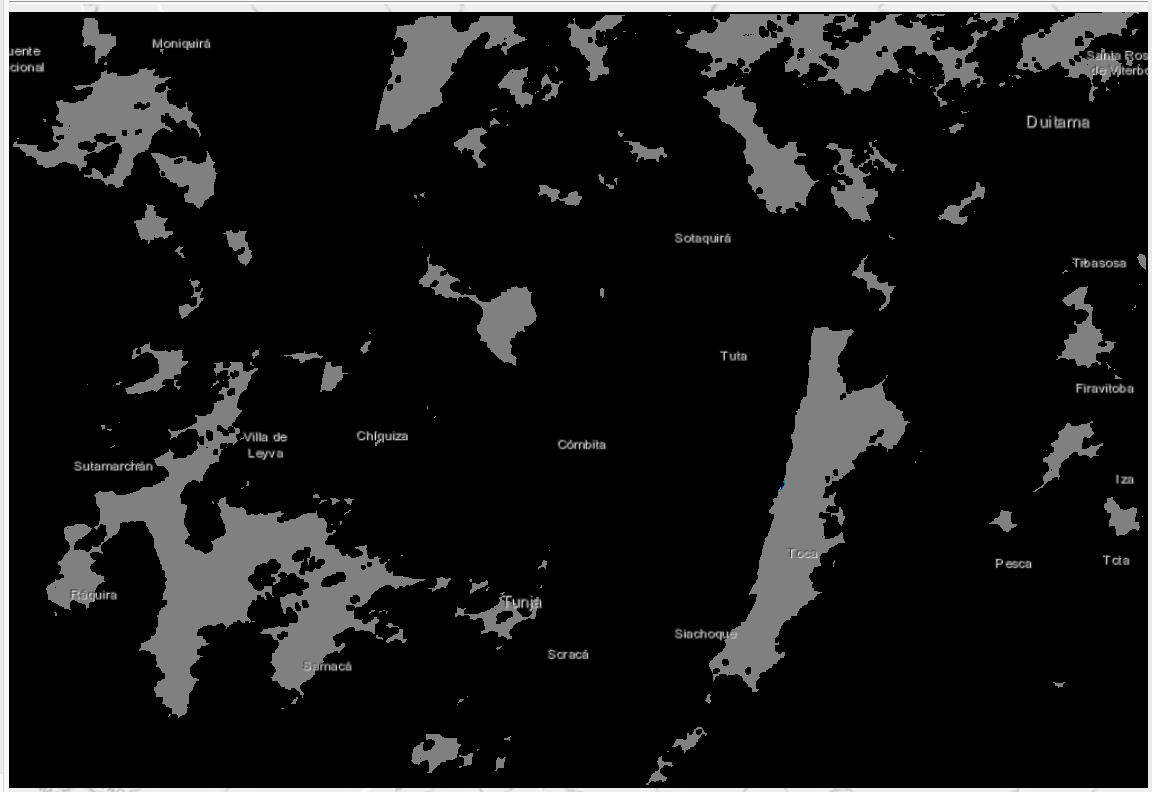

## 6.1  MOSAICOS MENSUALES DE LANDSAT 8 PARA EL PERIODO DE ANALISIS (2014 - 2024) ##

Genera y exportar composites mensuales de Landsat 8 Collection 2 Tier 1 Level-2 entre 2014 y 2024 para un AOI definido por shapefile. En términos operativos, el notebook: Lee un AOI desde shapefile y lo transforma a ee.Geometry en WGS84 (EPSG:4326), aplicando correcciones de geometría (validación, buffer(0), unión). Construye una colección mensual (ImageCollection) filtrada por fecha y AOI.

Aplica: enmascaramiento QA (nubes/sombras y saturación radiométrica), escalado a reflectancia para bandas SR, 
una máscara topográfica vía hillShadow (control de sombra por relieve), y calcula índices espectrales NDVI, EVI, NBR y NDWI. Calcula un composite mediana por mes. Añade una banda IMG_COUNT con el número de imágenes del mes.

Exporta cada composite a Google Drive como GeoTIFF (30 m), creando 11×12 = 132 tareas.

###  6.1.1 Parte 1 ###

Autenticación e inicialización de GEE; lectura y preparación del área de interes, reproyectar y validar geometria. Definición de funciones e índices. Se realiza mascara topografica usando el SRTM y geometría solar, devolviendo imagenes con bandas corregidas. Se emplean el índice NDVI, EVI, NBR y NDWI. Se define las fechas para el mosaico, filtrandose por fecha y área de interes. Se obtiene la mediana del mes y el número de iamgenes empleadas para el mosaico. Finalmente se exporta a google drive con resolcuión de 30 metros y se genera un reporte final por tareas. Los datos aquí suministrados, de momento, se manejan es sistema de coordenadas EPSG = 4326. 


In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
import ee
from src.gee_aoi import load_aoi_ee_geometry
from src.gee_export import setup_logger, run_monthly_exports

# 1) Auth solo cuando toque
ee.Authenticate()
ee.Initialize()

ruta_aoi_shp = r"D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\SHP\AOI_25_09_19.shp"
aoi = load_aoi_ee_geometry(ruta_aoi_shp, target_epsg=4326)

# params
year_start, year_end = 2014, 2024
folder_drive = "Imagenes_GEE"
scale = 30
dry_run = False  # True para probar sin lanzar tareas

log_path = os.path.join(os.getcwd(), "logs", "gee_exports.log")
logger = setup_logger(log_path)

tasks = run_monthly_exports(
    aoi=aoi,
    year_start=year_start,
    year_end=year_end,
    folder=folder_drive,
    scale=scale,
    logger=logger,
    dry_run=dry_run
)

print("Total tareas:", len(tasks))
tasks[:5]

Total tareas: 132


[TaskInfo(year=2014, month=1, desc='L8_2014_01'),
 TaskInfo(year=2014, month=2, desc='L8_2014_02'),
 TaskInfo(year=2014, month=3, desc='L8_2014_03'),
 TaskInfo(year=2014, month=4, desc='L8_2014_04'),
 TaskInfo(year=2014, month=5, desc='L8_2014_05')]

## 6.2 Preprocesamiento Imagenes Sentinel 1 GRD ##

Consulta la colección Sentinel-1 GRD (COPERNICUS/S1_GRD) para un año específico (YEAR_TO_RUN) y un sentido orbital (ASCENDING o DESCENDING). Genera dos productos complementarios: Un CSV índice (metadatos por escena) exportado a Google Drive; exportación de imágenes procesadas por lotes, con preprocesamiento SAR (máscara de borde, normalización gamma0, ratio VV/VH, filtrado speckle multitemporal y diferencia VV respecto a una referencia). Se descargaron 458 imagenes en orbita ascendente entre diciembre de 2014 y diciembre de 2021. No se encontraron imagenes para meses anteriores a diciembre de 2014 e incosistencia de imagenes mensuales para 2015 y 2016. No se encontraron imagenes de orbita ascendente desde el año 2022 al 2023.

### 6.2.1 Parte 1 ###

Inicializa GEE; construye el área de interes como ee.Geometry desde shapefile y define parámetros globales (año, órbita, tamaño de lote); define funciones de preprocesamiento SAR con orbita ascendente. Construcción de la colección Sentinel 1, definiendose la selección de escenas Sentienl 1 que intersectan el área de interes, estan dentro del año, son IW GRD, cuentan con polarizaciones VV y VH y para la orbita previamente definida (ascendente). Se realiza Speckle multitemporal basado en imágenes previas. Para cada imagen, se construye una mediana de las N_PREV_IMAGES inmediatamente anteriores (en tiempo), y luego suavizar espacialmente con un kernel boxcar. Se calcula Banda de diferencia VV respecto a referencia, permitiendo realizar cambios respecto a una condición base del año. Se exporta CSV con los metadatos de las imagenes

<span style="color:red">Incremente la ventana de días para que el primer mosaico tuviera más escenas que fueran representativas del mes y teniendo en cuenta que la resolución espacial es de 12 días, por eso deje una ventana de 6 días.Por ejemplo, para el pirmer mosaico de enero de 2017 salieron 3 escenas (dos escenas del 09 de enero y una escena del 14 de enero). El mosaico esta mezclando diferentes orbitas relativas, esto podría representar un error para buscar identificar cambios mensuales</span>

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# =========================
# 0) Imports base
# =========================
import json
import logging
from pathlib import Path
import sys
import ee
import pandas as pd

# =========================
# 1) PROJECT ROOT
# =========================
PROJECT_DIR = Path.cwd().resolve()

print("PROJECT_DIR:", PROJECT_DIR)
print("PROJECT_DIR exists:", PROJECT_DIR.exists())

CFG_PATH = PROJECT_DIR / "configs" / "Copy2_s1_default.json"
LOG_PATH = PROJECT_DIR / "logs" / "run.log"

print("CFG_PATH:", CFG_PATH)
print("CFG exists:", CFG_PATH.exists())

PROJECT_DIR: C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20
PROJECT_DIR exists: True
CFG_PATH: C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\configs\Copy2_s1_default.json
CFG exists: True


In [8]:
if not CFG_PATH.exists():
    raise FileNotFoundError(f"No existe el config en: {CFG_PATH}")

# =========================
# 2) Logging reproducible
# =========================
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=str(LOG_PATH),
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,  # importante en notebook para reconfigurar logging
)

logger = logging.getLogger("s1_pipeline")
logger.info("=== START RUN ===")

# =========================
# 3) Asegurar imports de src/
# =========================
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

# =========================
# 4) Imports del proyecto
# =========================
from src.aoi import aoi_shp_to_ee_geometry
from src.temporal_mosaics import build_temporal_mosaics
from src.radiometry import border_noise_mask, gamma0_db, terrain_flattening
from src.speckle import refined_lee_spatial
from src.Copy2_pipeline_sentinel1 import (
    build_pipeline,
    build_pipeline_base,
    build_pipeline_with_prepost,
    build_collection_by_pass,
)
from src.Copy2_indices import add_ratio_db, build_prepost_pairs_and_indices

# =========================
# 5) Earth Engine init
# =========================
try:
    ee.Initialize()
    print("Earth Engine inicializado correctamente.")
except Exception:
    print("Earth Engine no estaba inicializado. Ejecutando autenticación...")
    ee.Authenticate()
    ee.Initialize()
    print("Earth Engine autenticado e inicializado correctamente.")

# =========================
# 6) Cargar config
# =========================
cfg = json.loads(CFG_PATH.read_text(encoding="utf-8"))
print("Config cargado OK")
print(json.dumps(cfg, indent=2, ensure_ascii=False))

Earth Engine inicializado correctamente.
Config cargado OK
{
  "year": 2017,
  "orbit": "ASCENDING",
  "relative_orbit": null,
  "eps": 1e-10,
  "kernel_size": 7,
  "dem_id": "USGS/SRTMGL1_003",
  "window_days": 6,
  "start_date": "2017-03-01",
  "end_date": "2017-03-31",
  "mosaic_reducer": "median",
  "pre_max_gap_days": 60,
  "coverage_scale": 30,
  "min_overlap_pixels": 1000,
  "min_overlap_fraction_of_post": 0.2
}


In [10]:
required_keys = ["year", "orbit", "dem_id", "window_days"]
missing = [k for k in required_keys if k not in cfg]
if missing:
    raise KeyError(f"Faltan claves obligatorias en el config: {missing}")

logger.info(f"Config cargado: {cfg}")

# =========================
# 7) AOI desde shapefile
# =========================
AOI_PATH = r"D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\SHP\AOI_25_09_19.shp"

print("AOI_PATH:", AOI_PATH)
aoi = aoi_shp_to_ee_geometry(AOI_PATH)
print("AOI cargado correctamente.")

logger.info(f"AOI cargado desde: {AOI_PATH}")

AOI_PATH: D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\SHP\AOI_25_09_19.shp
AOI cargado correctamente.


In [12]:
# =========================
# 8) Parámetros derivados
# =========================
year = int(cfg["year"])
orbit = str(cfg["orbit"])
eps = float(cfg.get("eps", 1e-10))
kernel_size = int(cfg.get("kernel_size", 7))
dem_id = str(cfg["dem_id"])
window_days = int(cfg.get("window_days", 2))
start_date = str(cfg.get("start_date", f"{year}-01-01"))
end_date = str(cfg.get("end_date", f"{year + 1}-01-01"))
mosaic_reducer = str(cfg.get("mosaic_reducer", "median"))
pre_max_gap_days = int(cfg.get("pre_max_gap_days", 60))
relative_orbit = cfg.get("relative_orbit", None)

print("relative_orbit:", relative_orbit)
print("Parámetros principales:")
print("year:", year)
print("orbit:", orbit)
print("eps:", eps)
print("kernel_size:", kernel_size)
print("dem_id:", dem_id)
print("window_days:", window_days)
print("start_date:", start_date)
print("end_date:", end_date)
print("mosaic_reducer:", mosaic_reducer)
print("pre_max_gap_days:", pre_max_gap_days)

relative_orbit: None
Parámetros principales:
year: 2017
orbit: ASCENDING
eps: 1e-10
kernel_size: 7
dem_id: USGS/SRTMGL1_003
window_days: 6
start_date: 2017-03-01
end_date: 2017-03-31
mosaic_reducer: median
pre_max_gap_days: 60


In [14]:
# =========================
# 9) Funciones auxiliares de depuración
# =========================
def show_bands(col, label):
    size = col.size().getInfo()
    print(f"{label} -> size: {size}")
    if size > 0:
        img = ee.Image(col.first())
        print(f"{label} -> bands: {img.bandNames().getInfo()}")
    else:
        print(f"{label} -> colección vacía")


def show_first_date(col, label):
    size = col.size().getInfo()
    if size > 0:
        img = ee.Image(col.first())
        date_str = ee.Date(img.get("system:time_start")).format("YYYY-MM-dd").getInfo()
        print(f"{label} -> primera fecha: {date_str}")
    else:
        print(f"{label} -> sin fechas (colección vacía)")


def show_sample_properties(col, label, props=None):
    size = col.size().getInfo()
    if size == 0:
        print(f"{label} -> colección vacía")
        return

    if props is None:
        props = ["fecha_id", "conteo_imagenes", "window_start", "window_end", "delta_days"]

    img = ee.Image(col.first())
    values = {}
    for p in props:
        try:
            values[p] = img.get(p).getInfo()
        except Exception:
            values[p] = None

    print(f"{label} -> propiedades muestra:")
    for k, v in values.items():
        print(f"   {k}: {v}")

In [16]:
# =========================
# 10) Construcción paso a paso para validación
# =========================
print("\n=========================")
print("VALIDACIÓN PASO A PASO")
print("=========================\n")

# 10.1 Colección base
if relative_orbit is None:
    col0 = build_collection_by_pass(
        aoi=aoi,
        year=year,
        orbit_pass=orbit,
        start_date=start_date,
        end_date=end_date,
    )
else:
    col0 = build_collection_by_pass_and_relative_orbit(
        aoi=aoi,
        year=year,
        orbit_pass=orbit,
        relative_orbit=int(relative_orbit),
        start_date=start_date,
        end_date=end_date,
    )

show_bands(col0, "0) build_collection")
show_first_date(col0, "0) build_collection")

def collection_to_feature_df(col: ee.ImageCollection, max_items: int = 500) -> pd.DataFrame:
    n = col.size().getInfo()
    n_use = min(n, max_items)
    img_list = col.toList(n_use)

    rows = []
    for i in range(n_use):
        img = ee.Image(img_list.get(i))
        props = img.toDictionary([
            "system:index",
            "system:time_start",
            "orbitProperties_pass",
            "relativeOrbitNumber_start",
            "sliceNumber",
            "platform_number",
            "instrumentMode",
            "productType",
            "transmitterReceiverPolarisation",
            "resolution_meters",
            "resolution",
            "orbitNumber_start"
        ]).getInfo()

        rows.append({
            "idx": i,
            "system_index": props.get("system:index"),
            "system_time_start": props.get("system:time_start"),
            "date": pd.to_datetime(props.get("system:time_start"), unit="ms", errors="coerce"),
            "orbit_pass": props.get("orbitProperties_pass"),
            "relative_orbit": props.get("relativeOrbitNumber_start"),
            "slice_number": props.get("sliceNumber"),
            "platform": props.get("platform_number"),
            "instrument_mode": props.get("instrumentMode"),
            "product_type": props.get("productType"),
            "polarizations": str(props.get("transmitterReceiverPolarisation")),
            "resolution_meters": props.get("resolution_meters"),
            "resolution": props.get("resolution"),
            "orbit_number_start": props.get("orbitNumber_start"),
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("date").reset_index(drop=True)
    return df

df_col0 = collection_to_feature_df(col0, max_items=500)
print(df_col0.head(20))
print("Total imágenes en col0:", len(df_col0))

summary_pass = (
    df_col0.groupby("orbit_pass", dropna=False)
    .agg(
        n_scenes=("system_index", "count"),
        n_relative_orbits=("relative_orbit", "nunique"),
        n_slices=("slice_number", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)

summary_rel_orbit = (
    df_col0.groupby("relative_orbit", dropna=False)
    .agg(
        n_scenes=("system_index", "count"),
        n_slices=("slice_number", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
    .sort_values("n_scenes", ascending=False)
)

summary_pass_rel = (
    df_col0.groupby(["orbit_pass", "relative_orbit"], dropna=False)
    .agg(
        n_scenes=("system_index", "count"),
        n_slices=("slice_number", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
    .sort_values(["orbit_pass", "n_scenes"], ascending=[True, False])
)

summary_slice = (
    df_col0.groupby("slice_number", dropna=False)
    .agg(
        n_scenes=("system_index", "count"),
        n_relative_orbits=("relative_orbit", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
    .sort_values("n_scenes", ascending=False)
)

print("\nResumen por pase")
print(summary_pass)

print("\nResumen por órbita relativa")
print(summary_rel_orbit)

print("\nResumen por pase + órbita relativa")
print(summary_pass_rel)

print("\nResumen por slice")
print(summary_slice)


# 10.2 Mosaicos temporales
col1 = build_temporal_mosaics(
    col=col0,
    aoi=aoi,
    start_date=start_date,
    end_date=end_date,
    window_days=window_days,
    reducer=mosaic_reducer,
)
show_bands(col1, "1) build_temporal_mosaics")
show_first_date(col1, "1) build_temporal_mosaics")
show_sample_properties(col1, "1) build_temporal_mosaics")

def inspect_mosaic_windows(col_raw: ee.ImageCollection, col_mosaic: ee.ImageCollection, max_mosaics: int = 20):
    n = min(col_mosaic.size().getInfo(), max_mosaics)
    mosaic_list = col_mosaic.toList(n)

    rows = []
    for i in range(n):
        mosaic = ee.Image(mosaic_list.get(i))

        window_start = mosaic.get("window_start").getInfo()
        window_end = mosaic.get("window_end").getInfo()
        fecha_id = mosaic.get("fecha_id").getInfo()
        conteo_imagenes = mosaic.get("conteo_imagenes").getInfo()

        subset = col_raw.filterDate(window_start, window_end)
        df_subset = collection_to_feature_df(subset, max_items=100)

        rel_orbits = sorted(df_subset["relative_orbit"].dropna().unique().tolist()) if not df_subset.empty else []
        slices = sorted(df_subset["slice_number"].dropna().unique().tolist()) if not df_subset.empty else []

        rows.append({
            "mosaic_idx": i,
            "fecha_id": fecha_id,
            "window_start": window_start,
            "window_end": window_end,
            "conteo_imagenes": conteo_imagenes,
            "n_relative_orbits": len(rel_orbits),
            "relative_orbits": rel_orbits,
            "n_slices": len(slices),
            "slices": slices,
        })

    return pd.DataFrame(rows)

df_windows = inspect_mosaic_windows(col0, col1, max_mosaics=20)
print(df_windows)

# 10.3 Máscara de borde
col2 = col1.map(border_noise_mask)
show_bands(col2, "2) + border_noise_mask")
show_first_date(col2, "2) + border_noise_mask")
show_sample_properties(col2, "2) + border_noise_mask")

# 10.4 Gamma0
col3 = col2.map(gamma0_db)
show_bands(col3, "3) + gamma0_db")
show_first_date(col3, "3) + gamma0_db")
show_sample_properties(col3, "3) + gamma0_db")

# 10.5 Terrain flattening
dem = ee.Image(dem_id)
col4 = col3.map(lambda img: terrain_flattening(img, dem=dem))
show_bands(col4, "4) + terrain_flattening")
show_first_date(col4, "4) + terrain_flattening")
show_sample_properties(col4, "4) + terrain_flattening")

# 10.6 Speckle
col5 = col4.map(lambda img: refined_lee_spatial(img, kernel_size=kernel_size))
show_bands(col5, "5) + refined_lee_spatial")
show_first_date(col5, "5) + refined_lee_spatial")
show_sample_properties(col5, "5) + refined_lee_spatial")

# 10.7 Ratio VV/VH
col6 = col5.map(lambda img: add_ratio_db(img, eps=eps))
show_bands(col6, "6) + add_ratio_db")
show_first_date(col6, "6) + add_ratio_db")
show_sample_properties(col6, "6) + add_ratio_db")

# 10.8 Flujo base sin pre/post
#col7 = col6.sort("system:time_start")
#show_bands(col7, "7) flujo base SIN pre/post")
#show_first_date(col7, "7) flujo base SIN pre/post")
#show_sample_properties(col7, "7) flujo base SIN pre/post")

# 10.8 Índices pre/post reactivados
col7 = build_prepost_pairs_and_indices(
    col=col6,
    aoi=aoi,
    eps=eps,
    max_gap_days=pre_max_gap_days,
    coverage_scale=int(cfg.get("coverage_scale", 30)),
    min_overlap_pixels=float(cfg.get("min_overlap_pixels", 1000)),
    min_overlap_fraction_of_post=float(cfg.get("min_overlap_fraction_of_post", 0.20)),
)

show_bands(col7, "7) + build_prepost_pairs_and_indices")
show_first_date(col7, "7) + build_prepost_pairs_and_indices")
show_sample_properties(
    col7,
    "7) + build_prepost_pairs_and_indices",
    props=[
        "fecha_id",
        "conteo_imagenes",
        "window_start",
        "window_end",
        "pre_time",
        "post_time",
        "delta_days",
        "has_pre_pair",
        "pre_index",
        "overlap_vv",
        "overlap_frac_vv",
    ],
)

# =========================
# 11) Pipeline completo
# =========================
print("\n=========================")
print("PIPELINE COMPLETO")
print("=========================\n")

# Durante esta prueba, build_pipeline() apunta al flujo base.
#col_final = build_pipeline(aoi, cfg)

# build_pipeline() se mantiene en base.
# Para reactivar pre/post, aquí llamamos explícitamente al flujo extendido.
col_final = build_pipeline_with_prepost(aoi, cfg)

n_final = col_final.size().getInfo()
print("N imágenes finales:", n_final)

if n_final == 0:
    raise ValueError(
        "La colección final quedó vacía. "
        "Revisa AOI, fechas, órbita, ventana temporal o max_gap_days."
    )

first_img = ee.Image(col_final.first())
bands_final = first_img.bandNames().getInfo()

print("Bandas finales:", bands_final)
print("Primera fecha final:", ee.Date(first_img.get("system:time_start")).format("YYYY-MM-dd").getInfo())

logger.info(f"N imágenes finales: {n_final}")
logger.info(f"Bandas finales: {bands_final}")

# =========================
# 12) Verificación adicional de propiedades
# =========================
print("\n=========================")
print("PROPIEDADES DE LA PRIMERA IMAGEN FINAL")
print("=========================\n")

#props_to_check = [
#    "fecha_id",
#    "conteo_imagenes",
#    "window_start",
#    "window_end",
#    "window_days",
#    "aggregation",
#]

props_to_check = [
    "fecha_id",
    "conteo_imagenes",
    "window_start",
    "window_end",
    "window_days",
    "aggregation",
    "pre_time",
    "post_time",
    "delta_days",
    "has_pre_pair",
    "pre_index",
    "pair_selection",
    "overlap_vv",
    "overlap_vh",
    "overlap_frac_vv",
    "overlap_frac_vh",
]

for p in props_to_check:
    try:
        print(f"{p}: {first_img.get(p).getInfo()}")
    except Exception:
        print(f"{p}: <no disponible>")

# =========================
# 13) Lista de bandas a exportar
# =========================
#EXPORT_BANDS = [
#    "VV",
#    "VH",
#    "angle",
#    "VVVH_ratio",
#]

EXPORT_BANDS = [
    "VV",
    "VH",
    "angle",
    "VVVH_ratio",
    "VV_Difference",
    "VH_Difference",
    "VHVV_Difference",
]

print("\nEXPORT_BANDS:", EXPORT_BANDS)

missing_bands = [b for b in EXPORT_BANDS if b not in bands_final]
if missing_bands:
    raise ValueError(f"Faltan bandas para exportar: {missing_bands}")

# =========================
# 14) Función de exportación por lotes
# =========================
def export_batch_to_drive(
    col,
    aoi,
    year,
    folder,
    scale,
    max_pixels,
    batch_start=0,
    batch_size=10,
    export_bands=None,
):
    """
    Exporta por lotes imágenes de una ee.ImageCollection a Google Drive.

    Parámetros
    ----------
    col : ee.ImageCollection
    aoi : ee.Geometry
    year : int
    folder : str
        Carpeta en Google Drive.
    scale : int | float
        Resolución de exportación.
    max_pixels : int | float
        Máximo de píxeles permitido por GEE.
    batch_start : int
        Índice inicial del lote.
    batch_size : int
        Número de imágenes a exportar.
    export_bands : list[str] | None
        Bandas a exportar.
    """
    if export_bands is None:
        export_bands = EXPORT_BANDS

    n = col.size().getInfo()
    print(f"[EXPORT] year={year} -> n_images={n}")

    if n == 0:
        print("[EXPORT] Colección vacía. No se crean tareas.")
        return []

    batch_end = min(batch_start + batch_size, n)

    if batch_start >= n:
        raise ValueError(f"batch_start={batch_start} >= n={n}")

    img_list = col.toList(n)
    tasks = []

    for i in range(batch_start, batch_end):
        img = ee.Image(img_list.get(i))

        try:
            fecha_id = img.get("fecha_id").getInfo()
        except Exception:
            fecha_id = f"{year}_{i}"

        # nombre más informativo
        desc = f"S1_{fecha_id}_{i}"

        out = img.select(export_bands).toFloat().clip(aoi)

        task = ee.batch.Export.image.toDrive(
            image=out,
            description=desc,
            folder=folder,
            fileNamePrefix=desc,
            region=aoi,
            scale=scale,
            maxPixels=max_pixels,
            fileFormat="GeoTIFF",
        )
        task.start()
        tasks.append(task)

        print(f"[EXPORT] Lanzada tarea {i}: {desc}")

    print(f"[EXPORT] Tareas lanzadas: {len(tasks)} ({batch_start}..{batch_end - 1})")
    print(f"[EXPORT] Siguiente batch_start sugerido: {batch_end}")

    return tasks

# =========================
# 15) Vista rápida de fechas disponibles
# =========================
print("\n=========================")
print("FECHAS DISPONIBLES")
print("=========================\n")

try:
    fechas = col_final.aggregate_array("fecha_id").getInfo()
    print("Primeras 20 fechas:")
    for f in fechas[:20]:
        print(" -", f)
except Exception as e:
    print("No fue posible extraer fechas:", e)

# =========================
# 16) Exportación
# =========================
# Ajusta estos parámetros según tu necesidad
DRIVE_FOLDER = "Imagenes_GEE"
EXPORT_SCALE = 30
EXPORT_MAX_PIXELS = 1e13
BATCH_START = 0
BATCH_SIZE = 5

print("\n=========================")
print("EXPORTACIÓN")
print("=========================\n")
print("Carpeta Drive:", DRIVE_FOLDER)
print("Scale:", EXPORT_SCALE)
print("Max pixels:", EXPORT_MAX_PIXELS)
print("Batch start:", BATCH_START)
print("Batch size:", BATCH_SIZE)

tasks = export_batch_to_drive(
    col=col_final,
    aoi=aoi,
    year=year,
    folder=DRIVE_FOLDER,
    scale=EXPORT_SCALE,
    max_pixels=EXPORT_MAX_PIXELS,
    batch_start=BATCH_START,
    batch_size=BATCH_SIZE,
    export_bands=EXPORT_BANDS,
)

print(f"\nSe lanzaron {len(tasks)} tareas.")

logger.info(f"Tareas exportadas: {len(tasks)}")
logger.info("=== END RUN ===")


VALIDACIÓN PASO A PASO

0) build_collection -> size: 8
0) build_collection -> bands: ['VV', 'VH', 'angle']
0) build_collection -> primera fecha: 2017-03-03
   idx                                       system_index  system_time_start  \
0    0  S1B_IW_GRDH_1SDV_20170303T231313_20170303T2313...      1488582793000   
1    1  S1B_IW_GRDH_1SDV_20170310T230451_20170310T2305...      1489187091000   
2    2  S1B_IW_GRDH_1SDV_20170310T230516_20170310T2305...      1489187116000   
3    3  S1B_IW_GRDH_1SDV_20170315T231313_20170315T2313...      1489619593970   
4    4  S1B_IW_GRDH_1SDV_20170322T230451_20170322T2305...      1490223891260   
5    5  S1B_IW_GRDH_1SDV_20170322T230516_20170322T2305...      1490223916270   
6    6  S1B_IW_GRDH_1SDV_20170327T231257_20170327T2313...      1490656377300   
7    7  S1B_IW_GRDH_1SDV_20170327T231322_20170327T2313...      1490656402000   

                     date orbit_pass  relative_orbit  slice_number platform  \
0 2017-03-03 23:13:13.000  ASCENDING       

EEException: Too many concurrent aggregations.

In [ ]:
print("Bandas finales:", bands_final)

for p in ["fecha_id", "window_start", "window_end", "aggregation"]:
    try:
        print(p, ":", first_img.get(p).getInfo())
    except Exception:
        print(p, ": <no disponible>")

In [ ]:
img_mosaic = ee.Image(col1.first())
img_final = ee.Image(col_final.first())

print("MOSAIC projection:", img_mosaic.select("VV").projection().getInfo())
print("FINAL projection:", img_final.select("VV").projection().getInfo())

print("MOSAIC geometry:", img_mosaic.geometry().bounds().getInfo())
print("FINAL geometry:", img_final.geometry().bounds().getInfo())

In [ ]:
def valid_pixel_count(img, band, region, scale=30):
    stats = img.select(band).mask().reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region,
        scale=scale,
        maxPixels=1e13
    ).getInfo()
    return stats

imgs = {
    "mosaic": ee.Image(col1.first()),
    "border": ee.Image(col2.first()),
    "gamma0": ee.Image(col3.first()),
    "terrain": ee.Image(col4.first()),
    "lee": ee.Image(col5.first()),
    "ratio": ee.Image(col6.first()),
    "final": ee.Image(col7.first()),
}

for name, img in imgs.items():
    try:
        print(f"\n{name}")
        print("VV:", valid_pixel_count(img, "VV", aoi))
    except Exception as e:
        print(f"{name} -> error: {e}")

In [ ]:
def count_valid(img, band, region, scale=30):
    return img.select(band).mask().reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region,
        scale=scale,
        maxPixels=1e13
    ).getInfo()

In [ ]:
df_col0 = collection_to_feature_df(col0, max_items=500)
print(df_col0.head(20))
print("\nTotal imágenes:", len(df_col0))

In [ ]:
chronological_table = df_col0[
    [
        "date",
        "orbit_pass",
        "relative_orbit",
        "slice_number",
        "platform",
        "system_index",
        "polarizations"
    ]
].sort_values("date").reset_index(drop=True)

print(chronological_table.head(20))

In [ ]:
out_dir = r"D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\XLS\outputs_diagnostico"
import os
os.makedirs(out_dir, exist_ok=True)

df_col0.to_csv(os.path.join(out_dir, "coleccion_detallada201703.csv"), index=False)
summary_pass.to_csv(os.path.join(out_dir, "resumen_por_pase201703.csv"), index=False)
summary_rel_orbit.to_csv(os.path.join(out_dir, "resumen_por_orbita_relativa201703.csv"), index=False)
summary_pass_rel.to_csv(os.path.join(out_dir, "resumen_por_pase_orbita201703.csv"), index=False)
summary_slice.to_csv(os.path.join(out_dir, "resumen_por_slice201703.csv"), index=False)
chronological_table.to_csv(os.path.join(out_dir, "tabla_cronologica201703.csv"), index=False)
df_windows.to_csv(os.path.join(out_dir, "resumen_ventanas_mosaico201703.csv"), index=False)

print("CSV exportados en:", out_dir)

### 6.2.2  Parte 1 ###

Selección de mejores escenas Sentinel 1 por mes. Debido a que se contaba con varias imagenes por mes, se busca identificar la imagen que mayor representatividad tenga del mes. Se implementa un flujo de control de calidad y selección objetiva de escenas Sentinel-1 a partir de un conjunto de GeoTIFF (patrón S1_201910*.tif). El objetivo operativo es: Recortar cada raster al área de interes y homogenizar NoData como NaN; medir validez de píxeles por banda y global; calcular estadística descriptiva por banda y por escena; generar histogramas para inspección visual; ejecutar un ranking final para seleccionar la mejor escena, priorizando: máximo porcentaje de píxeles válidos en todas las bandas, mínimo porcentaje de nulos en cualquier banda, desempate por coherencia geométrica y opcionalmente y coherencia orbital/slice usando un CSV índice.

Se identifica que la mayoria de imagenes son similares para los meses de analisis por lo que pdría escogerse cualquiera

Definir rutas, parámetros y configuración de salida; leer AOI, limpiar geometrías y validar. Inferir orden de bandas y loop por cada TIFF: máscara con el área de interes, inferencia de bandas, huella geométrica y comparación de grilla, métricas de validez por banda y global, estadística descriptiva por banda e histograma por banda. Se contruye reporte y ranking para establecer el orden, desempate por grilla y desempate por orbita. Selección de la mejor escena y reporte tecnico.

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from pathlib import Path
import logging

from src.config_histogra_sentinel1 import load_config
from src.pipeline_histograma_sentinel1 import run_qc_batch

PROJECT = Path.cwd()
cfg = load_config(PROJECT / "configs" / "qc_s1_batch.json")

log_path = PROJECT / "logs" / "qc_s1_batch.log"
log_path.parent.mkdir(exist_ok=True)

logging.basicConfig(
    filename=str(log_path),
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("qc_s1_batch")

res = run_qc_batch(cfg, logger)

display(res["df_consolidated_rank"].head(20))
print("Reporte consolidado:", res["paths"]["global_report_txt"])
print("Ranking consolidado:", res["paths"]["global_rank_csv"])

,folder,file,path,total_px_aoi,bands_used,valid_allbands_px,valid_allbands_pct,null_anyband_px,null_anyband_pct,geom_match_ref,...,VH_null_px,VH_null_pct,angle_valid_px,angle_valid_pct,angle_null_px,angle_null_pct,VVVH_ratio_valid_px,VVVH_ratio_valid_pct,VVVH_ratio_null_px,VVVH_ratio_null_pct
0,S1_2015_09,S1_2015_4.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,4837824,"VV,VH,angle,VVVH_ratio",1327162,27.433036,3510662,72.566964,True,...,3482878,71.992656,1449662,29.965166,3388162,70.034834,1354946,28.007344,3482878,71.992656
1,S1_2015_11,S1_2015_5.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,4836008,"VV,VH,angle,VVVH_ratio",1325275,27.404318,3510733,72.595682,True,...,3482974,72.021676,1451505,30.014529,3384503,69.985471,1353034,27.978324,3482974,72.021676
2,S1_2015_05,S1_2015_2.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,4836008,"VV,VH,angle,VVVH_ratio",1214224,25.107982,3621784,74.892018,False,...,3596859,74.376614,1491285,30.837108,3344723,69.162892,1239149,25.623386,3596859,74.376614
3,S1_2016_11,S1_2016_16.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,4836008,"VV,VH,angle,VVVH_ratio",824733,17.054004,4011275,82.945996,False,...,4011275,82.945996,1456265,30.112957,3379743,69.887043,1355731,28.034093,3480277,71.965907
4,S1_2016_09,S1_2016_7.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,4837824,"VV,VH,angle,VVVH_ratio",823585,17.023873,4014239,82.976127,False,...,3483963,72.015084,1453501,30.044520,3384323,69.955480,1353861,27.984916,3483963,72.015084
5,S1_2016_09,S1_2016_6.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,4836008,"VV,VH,angle,VVVH_ratio",822716,17.012296,4013292,82.987704,True,...,3483813,72.039025,1423172,29.428653,3412836,70.571347,1352195,27.960975,3483813,72.039025
6,S1_2016_12,S1_2016_19.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,4836008,"VV,VH,angle,VVVH_ratio",821662,16.990501,4014346,83.009499,True,...,4014346,83.009499,1451340,30.011117,3384668,69.988883,1350292,27.921625,3485716,72.078375
7,S1_2016_11,S1_2016_13.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,4836008,"VV,VH,angle,VVVH_ratio",821268,16.982354,4014740,83.017646,True,...,3486279,72.090017,1450161,29.986737,3385847,70.013263,1349729,27.909983,3486279,72.090017
8,S1_2017_05,S1_2017_25.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,4837824,"VV,VH,angle,VVVH_ratio",821358,16.977840,4016466,83.022160,False,...,3487360,72.085301,1450283,29.978003,3387541,70.021997,1350464,27.914699,3487360,72.085301
9,S1_2016_03,S1_2016_2.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,4836008,"VV,VH,angle,VVVH_ratio",819978,16.955679,4016030,83.044321,True,...,3488400,72.133876,1547738,32.004455,3288270,67.995545,819978,16.955679,4016030,83.044321


Reporte consolidado: outputs\qc_s1_batch_noVVDIFF\reporte_consolidado.txt
Ranking consolidado: outputs\qc_s1_batch_noVVDIFF\ranking_consolidado.csv


### 6.2.3  Parte 1 ###

Control de calidad para validez de retrodispersión por pixel, util para modelo de clasificación Random Forest. Control de calidad por “dominios de validez” sobre un conjunto de imagenes Sentinel-1 recortados para un área de interes. Se cuantifica, por escena, cuánto se reduce el conjunto de píxeles utilizables cuando se exige trazabilidad entre distintas combinaciones de bandas. En lugar de evaluar validez “banda por banda” de forma aislada, se calcula la intersección de validez: un píxel es apto para un dominio si es finito en todas las bandas del dominio. Dando por resultado que la mejor combinación es VV + VH + Angle. VV/VH y VV_Difference no cuentan con suficiente cobertura a lo largo de la imagen.

Se definen rutas, dominios y salidas y reproyección del área de interes al CRS del raster. Calculo de validez por dominio donde se cuentan los validos vs los nulos; las ganancias y perdidas marginales se ordenan desde el D1 al D5 identificando el costo de agregar variables para el Random Forest. Exportación de resultados y ranking para evaluar la mejor combinación de bandas para el Random Forest. Dando por resultado que la mejor combinación es VV + VH + Angle. Se analizaron 24 imagenes, de las cuales muy pocas contaban con la totalidad de las bandas; aquellas con la totalidad de las bandas solo cuentan con cobertura de cerca del 28% del área analizada.

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
from pathlib import Path
import logging
import sys

PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from src.pipeline_qc_s1 import run_qc
from src.config_qc_s1 import load_config

In [10]:
from pathlib import Path

configs_dir = PROJECT / "configs"
print("CONFIGS_DIR:", configs_dir)
print("Existe configs_dir?:", configs_dir.exists())

for f in configs_dir.glob("*.json"):
    print("Archivo encontrado:", f.name)

CONFIGS_DIR: C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\configs
Existe configs_dir?: True
Archivo encontrado: qc_s1_260312.json
Archivo encontrado: qc_s1_batch.json
Archivo encontrado: s1_default.json


In [14]:
cfg = load_config(PROJECT / "configs" / "qc_s1_260312.json")

log_path = PROJECT / "logs" / "qc_s1_230312.log"
log_path.parent.mkdir(exist_ok=True)

logging.basicConfig(
    filename=str(log_path),
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("qc_s1")

In [16]:
res = run_qc(cfg, logger)


In [18]:
display(res["df_rank"].head(10))
display(res["df_skipped"].head(10))

print("Dominios:", res["paths"]["domains_csv"])
print("Reporte:", res["paths"]["report_txt"])
print("Omitidos:", res["paths"]["skipped_csv"])

,file,path,geom_match_ref,total_px_aoi,D1_VV_bands,D1_VV_valid_px,D1_VV_valid_pct,D1_VV_null_px,D1_VV_null_pct,D2_VV_VH_bands,...,D5_VV_VH_angle_ratio_null_px,D5_VV_VH_angle_ratio_null_pct,gain_D1_VV_to_D2_VV_VH_pct,gain_D2_VV_VH_to_D3_VV_VH_angle_pct,gain_D3_VV_VH_angle_to_D4_VV_VH_ratio_pct,gain_D4_VV_VH_ratio_to_D5_VV_VH_angle_ratio_pct,gain_D2_to_D1_VV_pct,gain_D2_to_D3_VV_VH_angle_pct,gain_D2_to_D4_VV_VH_ratio_pct,gain_D2_to_D5_VV_VH_angle_ratio_pct
0,S1_2016_16.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,False,4836008,VV,1355731,28.034093,3480277,71.965907,"VV,VH",...,3480277,71.965907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,S1_2015_4.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,False,4837824,VV,1354946,28.007344,3482878,71.992656,"VV,VH",...,3482878,71.992656,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,S1_2016_7.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,False,4837824,VV,1353861,27.984916,3483963,72.015084,"VV,VH",...,3483963,72.015084,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,S1_2015_5.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,False,4836008,VV,1353034,27.978324,3482974,72.021676,"VV,VH",...,3482974,72.021676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,S1_2016_19.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,False,4836008,VV,1350292,27.921625,3485716,72.078375,"VV,VH",...,3485716,72.078375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,S1_2017_25.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,False,4837824,VV,1350464,27.914699,3487360,72.085301,"VV,VH",...,3487360,72.085301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,S1_2016_2.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,False,4836008,VV,1347608,27.866124,3488400,72.133876,"VV,VH",...,3488400,72.133876,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,S1_2015_2.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,True,4836008,VV,1239149,25.623386,3596859,74.376614,"VV,VH",...,3596859,74.376614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,S1_2020_20.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,False,4836008,VV,1086398,22.464768,3749610,77.535232,"VV,VH",...,3749610,77.535232,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,S1_2020_70.tif,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,False,4836008,VV,1085437,22.444897,3750571,77.555103,"VV,VH",...,3750571,77.555103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


""


Dominios: outputs\qc_s1_260312_multi_dominio\dominios_validos_s1_260312.csv
Reporte: outputs\qc_s1_260312_multi_dominio\reporte_dominios_s1_260312.txt
Omitidos: outputs\qc_s1_260312_multi_dominio\archivos_omitidos_s1_260312.csv


### 6.2.4  Parte 1 ###

Selección de orbita relativa para imagenes Sentinel 1 conforme a disponibilidad de puntos de incendio. Se asigna, para cada punto de incendio (proveniente de un shapefile con fecha desglosada), la órbita relativa de Sentinel-1 (relativeOrbitNumber_start) a partir de una tabla de metadatos (Excel). La lógica está diseñada para trabajar sin depender de campos como platform o temporalBaseline: la plataforma (S1A/S1B) se infiere desde el prefijo de system:index.

Para cada punto (fecha del incendio), el notebook intenta seleccionar una escena Sentinel-1 según tres escenarios temporales:

  A) Misma fecha exacta (si existe una escena ese día).

  B) Post-incendio: en la ventana [+1, +30] días, elige la más lejana (última fecha dentro de la ventana).

  C) Pre-incendio: en la ventana [−60, −30] días, elige la escena más cercana al objetivo fire_date − 30.

Cuando hay varias escenas candidatas para un mismo criterio/fecha, aplica un desempate determinístico: preferir plataforma S1A, preferir sliceNumber según un ranking definido por el usuario, desempate final por system:index. Finalmente exporta el resultado a un GeoPackage (GPKG).


Como resultado se obtuvo que las orbitas más comunes en el escenario Post-incendio son la orbita 77 y la 150. La orbita 150 es la que cuenta con más registros: con 237 puntos de incendio que cuentan con la orbita 150 que corresponden a 44 imagenes Sentinel 1. 

In [52]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
from pathlib import Path
import logging
import sys

# Detectar raíz del proyecto
PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from src.pipeline_fire_orbits import run_assignment

In [56]:
from src.config_fire_orbits import load_config

In [58]:
cfg = load_config(PROJECT / "configs" / "fire_orbits_260312.json")

log_path = PROJECT / "logs" / "fire_orbits_260312.log"
log_path.parent.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=str(log_path),
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger("fire_orbits")
logger.info("Inicio de ejecución fire_orbits_260312")

In [60]:
res = run_assignment(cfg, logger)

In [62]:
print("Resumen de asignación:")
print(res["summary"])

Resumen de asignación:
{'same_date_pct': 2.81, 'post_30_pct': 37.98, 'pre_30_pct': 38.92, 'n_points': 961}


In [64]:
display(res["gdf"].head())

,idx_firms,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,...,orb_post30,img_post30,idx_post30,slice_post30,orb_pre30,img_pre30,idx_pre30,slice_pre30,dt_post_days,dt_pre_days
0,7,5.78100,-73.56840,322.50,1.20,1.10,2014-09-29,1835,Aqua,MODIS,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,8,5.77960,-73.57840,318.10,1.20,1.10,2014-09-29,1835,Aqua,MODIS,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,16,5.47922,-73.51354,295.42,0.39,0.44,2014-02-04,0645,N,VIIRS,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,17,5.47701,-73.52529,300.45,0.39,0.44,2014-02-04,0645,N,VIIRS,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,21,5.61784,-73.31963,340.57,0.42,0.38,2014-02-02,1826,N,VIIRS,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [66]:
# Exportar a shapefile
out_path = cfg.out_dir / cfg.out_name
cfg.out_dir.mkdir(parents=True, exist_ok=True)

gdf_out = res["gdf"].copy()

for c in ["img_same", "img_post30", "img_pre30"]:
    gdf_out[c] = gdf_out[c].astype(str)

gdf_out.to_file(out_path)

print(f"Shapefile guardado en: {out_path}")
logger.info(f"Shapefile guardado en: {out_path}")

Shapefile guardado en: outputs\fire_orbits\incendios_con_orbitas_26_03_12.shp


C:\Users\Equipo\AppData\Local\Temp\ipykernel_26344\544626802.py:10: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_out.to_file(out_path)
C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field acq_date create as date field, though DateTime requested.
  ogr_write(
C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field acq_date_n create as date field, though DateTime requested.
  ogr_write(
C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field fecha_FIRM create as date field, though DateTime requested.
  ogr_write(
C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field fecha_UNGR create as date field, though DateTime requested.
  ogr_write(
C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field fire_date create as date field, though DateTime requested.
  ogr_write(
C:\Users\Equ

In [68]:
# Resúmenes opcionales
if res["gdf"]["dt_post_days"].notna().any():
    print("\nPost delta days:")
    print(res["gdf"]["dt_post_days"].dropna().describe())

if res["gdf"]["dt_pre_days"].notna().any():
    print("\nPre delta days:")
    print(res["gdf"]["dt_pre_days"].dropna().describe())


Post delta days:
count     365
unique     20
top        26
freq       75
Name: dt_post_days, dtype: int64

Pre delta days:
count     374
unique     28
top       -33
freq       62
Name: dt_pre_days, dtype: int64


### 6.2.5  Parte 1 ###

Extraer series Sentinel 1 en puntos y graficar multitemporal. Se extrae para un conjunto de puntos, los valores de varias variables Sentinel 1 a lo largo de una serie temporal de imagenes. Se busca construir una tabla larga con valores por punto por imagen por banda, generar estadisticas descriptivaas y graficos multitemporales que permitan analizar el comportamiento de la retrodispersión y variables derivadas

El puntos 480 y 482 se reporta incendio en la plataforma FIRMS en 01 de marzo de 2020; el punto 483 reporta incendio el 03 de febrero de 2020; punto 501 de 24 de abril de 2021; el punto 904 reporto incendio el 14 de febrero de 2024

In [6]:
import geopandas as gpd
import pandas as pd

INC_PATH = r"C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\outputs\fire_orbits\incendios_con_orbitas_26_03_12.shp"
NOINC_PATH = r"D:\Maestria_Geomatica\Semestre_IV\Puntos_unificados_25_11_05\Puntos_unificados_26_02_23\puntos_no_calientes_aleatorios_961_26_02_23.shp"


shape1 = gpd.read_file(INC_PATH)
shape2 = gpd.read_file(NOINC_PATH)

In [11]:
if shape1.crs != shape2.crs:
    shape2 = shape2.to_crs(shape1.crs)

# 3. Unir los archivos (Concatenación)

union = gpd.GeoDataFrame(pd.concat([shape1, shape2], ignore_index=True))

# 4. Guardar el resultado
union.to_file('Union_Incendio_NoIncendio_26_03_17.shp')

print("¡Archivos unidos con éxito!")

¡Archivos unidos con éxito!


C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field acq_date create as date field, though DateTime requested.
  ogr_write(
C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field acq_date_n create as date field, though DateTime requested.
  ogr_write(
C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field fecha_FIRM create as date field, though DateTime requested.
  ogr_write(
C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field fecha_UNGR create as date field, though DateTime requested.
  ogr_write(
C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field fire_date create as date field, though DateTime requested.
  ogr_write(


In [13]:
#shape almacenado en D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\SHP#

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from pathlib import Path
import logging
import sys

PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from src.config_s1_timeseries import load_config
from src.pipeline_s1_timeseries import run_pipeline
from src.io_metadata import load_metadata
from src.utils_raster import list_tifs
from src.temporal_matching import build_temporal_matches

In [9]:
cfg = load_config(PROJECT / "configs" / "s1_timeseries.json")

log_path = PROJECT / "logs" / "s1_timeseries.log"
log_path.parent.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=str(log_path),
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger("s1_timeseries")
logger.info("Inicio pipeline Sentinel-1 timeseries")

In [11]:
meta = load_metadata(cfg.metadata_xlsx)
tif_paths = list_tifs(cfg.raster_dir)
df_match = build_temporal_matches(tif_paths, meta)

print(df_match.head())
print("Total matches:", len(df_match))
print("Máximo delta al objetivo:", df_match["delta_days_to_target"].max())

  image_name_actual                                 raster_path_actual  \
0         S1_2015_2  D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...   
1         S1_2015_4  D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...   
2         S1_2015_5  D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...   
3        S1_2016_16  D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...   
4        S1_2016_19  D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...   

  date_actual image_name_pre   date_pre  delta_days_to_target  
0  2015-05-19      S1_2014_0 2014-12-02                   197  
1  2015-09-16      S1_2014_0 2014-12-02                    77  
2  2015-11-27      S1_2014_0 2014-12-02                     5  
3  2016-11-27      S1_2015_5 2015-11-27                     1  
4  2016-12-21      S1_2015_5 2015-11-27                    25  
Total matches: 24
Máximo delta al objetivo: 197


In [13]:
res = run_pipeline(cfg, logger)

In [45]:
selected_points = res["selected_points"]

In [47]:
import geopandas as gpd

gdf = gpd.read_file(cfg.layer_path)

# asegurar que exista point_id
if "point_id" not in gdf.columns:
    import numpy as np
    gdf = gdf.copy()
    gdf["point_id"] = np.arange(1, len(gdf) + 1)

gdf_sel = gdf[gdf["point_id"].isin(selected_points)]

gdf_sel

,idx_firms,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,...,slice_post,orb_pre30,img_pre30,idx_pre30,slice_pre3,dt_post_da,dt_pre_day,id,geometry,point_id
479,2598.0,5.45951,-73.56560,304.28,0.38,0.36,2020-03-01,0623,N20,VIIRS,...,7,77,2019-12-01 00:00:00,81,7,27,-33,NaN,POINT (4.94e+06 2.16e+06),480
481,2605.0,5.45456,-73.57690,295.21,0.38,0.36,2020-03-01,0623,N20,VIIRS,...,7,77,2019-12-01 00:00:00,81,7,27,-33,NaN,POINT (4.94e+06 2.16e+06),482
482,2618.0,5.45249,-73.57267,302.90,0.41,0.37,2020-02-03,0629,N20,VIIRS,...,7,77,2020-01-30 00:00:00,8,7,28,-32,NaN,POINT (4.94e+06 2.16e+06),483
500,2800.0,5.46244,-73.51491,330.13,0.40,0.37,2021-04-24,1810,N20,VIIRS,...,7,77,2021-03-25 00:00:00,19,7,30,-30,NaN,POINT (4.94e+06 2.16e+06),501
903,6381.0,5.46796,-73.55669,305.78,0.41,0.37,2024-02-14,0629,N20,VIIRS,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,POINT (4.94e+06 2.16e+06),904


In [14]:
display(res["df_match"].head())
display(res["df_long"].head())
display(res["df_stats"])

,image_name_actual,raster_path_actual,date_actual,image_name_pre,date_pre,delta_days_to_target
0,S1_2015_2,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,2015-05-19,S1_2014_0,2014-12-02,197
1,S1_2015_4,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,2015-09-16,S1_2014_0,2014-12-02,77
2,S1_2015_5,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,2015-11-27,S1_2014_0,2014-12-02,5
3,S1_2016_16,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,2016-11-27,S1_2015_5,2015-11-27,1
4,S1_2016_19,D:\Maestria_Geomatica\Semestre_IV\Tesis_Python...,2016-12-21,S1_2015_5,2015-11-27,25


,point_id,image_name,band,value
0,1,S1_2015_2,VV,-0.760459
1,2,S1_2015_2,VV,-4.133708
2,3,S1_2015_2,VV,-7.703681
3,4,S1_2015_2,VV,-8.384899
4,5,S1_2015_2,VV,NaN


,band,count,mean,std,min,p25,median,p75,max,nan_count
0,VV,18937.0,-8.083127,2.304618,-21.667158,-9.851176,-8.281418,-6.536308,5.620976,27191
1,VH,18937.0,-14.291273,1.994734,-26.965048,-15.677356,-14.432417,-12.994116,-6.449762,27191
2,angle,26061.0,45.240129,0.328919,44.170403,44.970856,45.226536,45.508080,45.999931,20067
3,VV_VH_Ratio,18937.0,6.208146,1.131393,2.557974,5.518049,6.068784,6.691688,17.856309,27191
4,VV_pre_post_ratio,3151.0,-0.825857,1.503797,-10.840474,-1.774287,-0.853209,0.258775,7.170736,42977
5,VH_pre_post_ratio,3151.0,-0.599680,1.237941,-5.331390,-1.413876,-0.613730,0.256964,4.491494,42977
6,VH_VV_ratio_change,3151.0,0.226178,1.000650,-6.341830,-0.370666,0.180684,0.775838,11.150661,42977


In [15]:
print("Puntos seleccionados:", res["selected_points"])
print("CSV largo:", res["paths"]["csv_long"])
print("Stats:", res["paths"]["stats"])
print("Plots:", res["paths"]["plots"])
print("Plots 5 puntos:", res["paths"]["plots_5"])
print("CSV 5 puntos:", res["paths"]["csv_5"])

Puntos seleccionados: [501, 480, 482, 483, 904]
CSV largo: outputs\s1_timeseries_features_26_03_17\extractions_long.csv
Stats: outputs\s1_timeseries_features_26_03_17\descriptive_stats_by_band.csv
Plots: outputs\s1_timeseries_features_26_03_17\plots
Plots 5 puntos: outputs\s1_timeseries_features_26_03_17\plots_5points
CSV 5 puntos: outputs\s1_timeseries_features_26_03_17\extractions_5points.csv


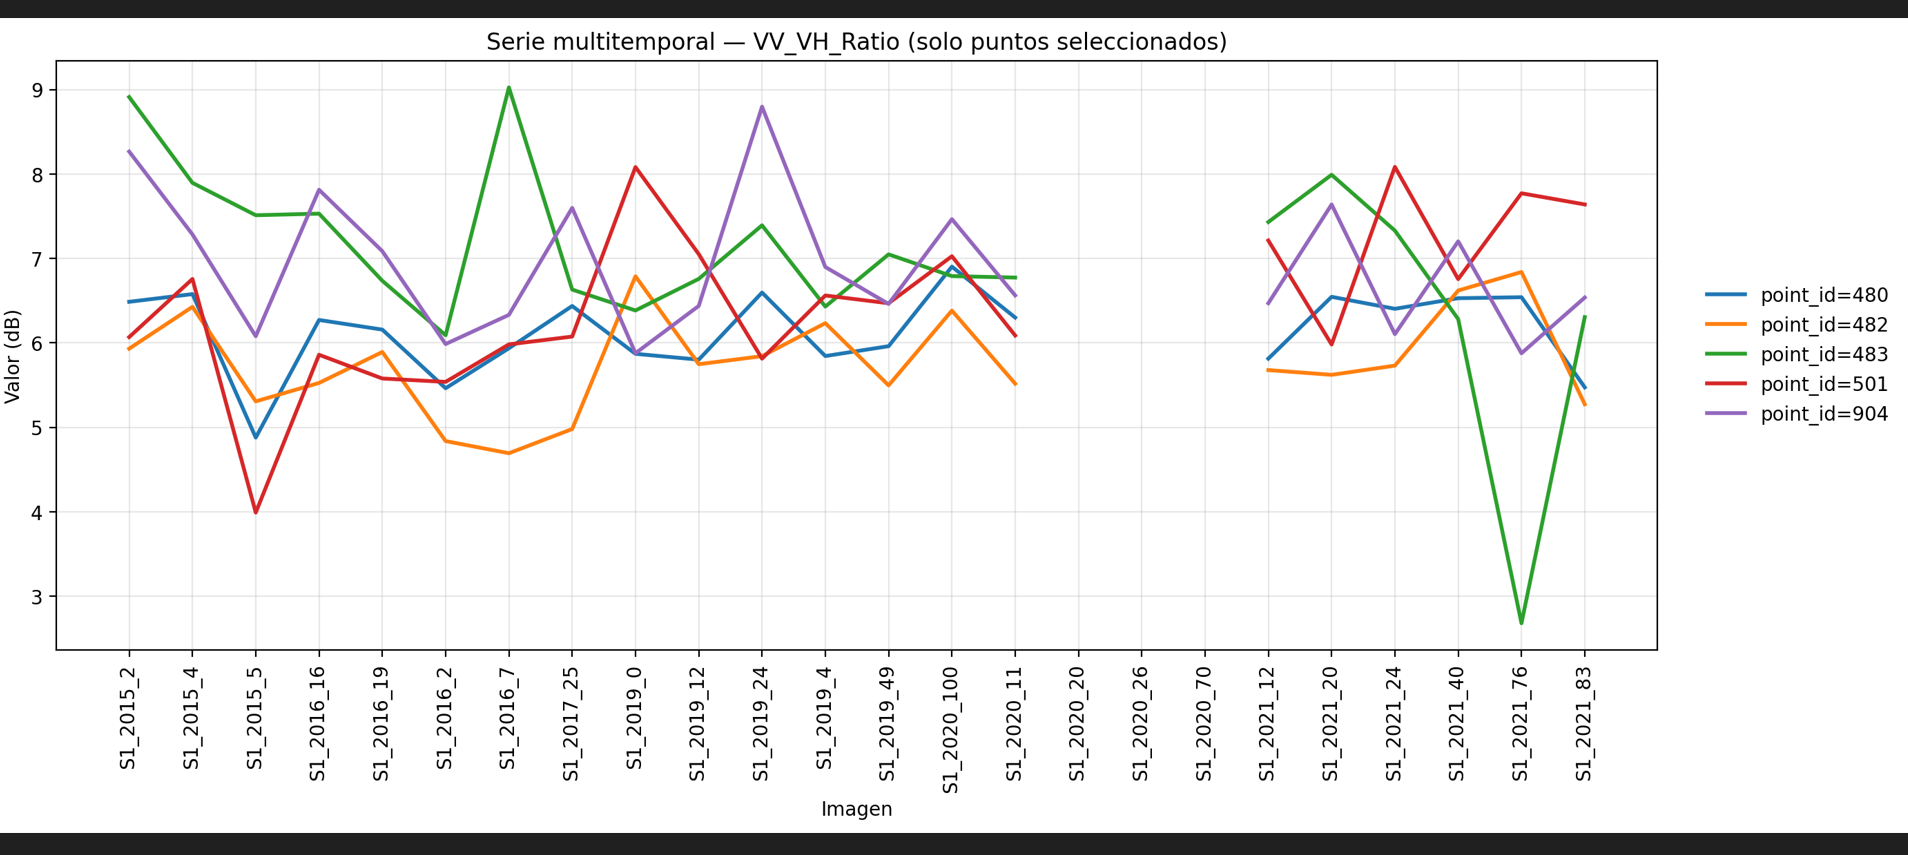